# EDA — 탐색에서 프레임워크로
전직 아마존 셀러가 카테고리 진입 의사결정을 데이터로 다시 푼다. 이 노트북은 **결론(스코어카드·모델)이 아니라
거기에 이르기까지의 탐색**을 보인다 — 어떤 데이터 특성이 Q1/Q2/Q3 설계와 정직한 한계(L-1~L-3)를
강제했는지. 모든 표/그림은 마트(`data/marts/*.parquet`)에서 직접 읽는다.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd, polars as pl
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
for f in ["AppleGothic","Arial Unicode MS","AppleSDGothicNeo"]:
    try: plt.rcParams["font.family"]=f; break
    except Exception: pass
plt.rcParams["axes.unicode_minus"]=False
ROOT = Path.cwd().parent if Path.cwd().name=="notebooks" else Path.cwd()
M = ROOT/"data"/"marts"
prod  = pl.read_parquet(M/"dim_product.parquet")
month = pl.read_parquet(M/"mart_niche_monthly.parquet")
score = pl.read_parquet(M/"mart_niche_score.parquet")
launch= pl.read_parquet(M/"mart_launch.parquet")
print("상품", prod.height, "| 니치-월", month.height, "| 스코어된 니치", score.height, "| 출시코호트", launch.height)

상품 5209394 | 니치-월 148620 | 스코어된 니치 906 | 출시코호트 2805103


## 1. 데이터 개요
규모와 시간 범위부터 본다. 분석 가능한 기간·코호트 수가 이후 split(Q3)과 추세 윈도우(Q1)를 정한다.

기간: {'from': datetime.date(2015, 1, 1), 'to': datetime.date(2023, 9, 1)}


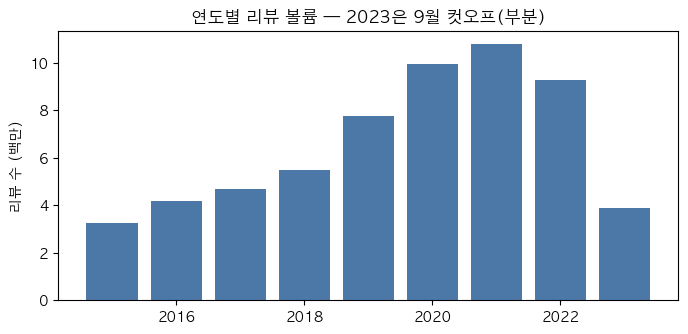

In [2]:
rng = month.select(pl.col("review_month").min().alias("from"), pl.col("review_month").max().alias("to"))
print("기간:", rng.to_dicts()[0])
by_year = (month.with_columns(pl.col("review_month").dt.year().alias("y"))
           .group_by("y").agg(pl.col("n_reviews").sum()).sort("y").to_pandas())
fig,ax=plt.subplots(figsize=(8,3.5))
ax.bar(by_year["y"], by_year["n_reviews"]/1e6, color="#4C78A8")
ax.set_ylabel("리뷰 수 (백만)"); ax.set_title("연도별 리뷰 볼륨 — 2023은 9월 컷오프(부분)")
plt.show()

## 2. 수요 프록시 점검 — 리뷰는 판매가 아니다 (L-1)
판매량 데이터가 없으므로 **월별 신규 리뷰 수**를 수요 프록시로 쓴다. 그러나 리뷰는 판매의 *불완전* 프록시라,
절대량 비교는 위험하다 → Q1에서 수요를 **증가율(추세)**로만 넣고 니치 간 절대 비교를 구조적으로 피한 이유.

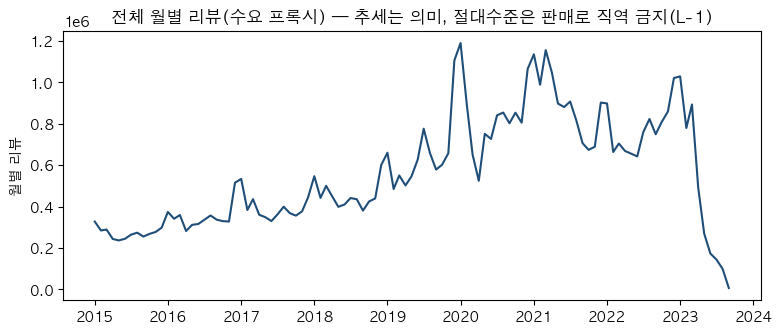

In [3]:
tot = (month.group_by("review_month").agg(pl.col("n_reviews").sum())
       .sort("review_month").to_pandas())
fig,ax=plt.subplots(figsize=(9,3.5))
ax.plot(tot["review_month"], tot["n_reviews"], color="#1f4e79")
ax.set_title("전체 월별 리뷰(수요 프록시) — 추세는 의미, 절대수준은 판매로 직역 금지(L-1)")
ax.set_ylabel("월별 리뷰"); plt.show()

## 3. 니치 크기 분포 → 왜 얇은 니치를 거르나 (Q1 필터 동기)
니치별 관측 개월수와 평균 활성 상품수를 보면 long-tail이 심하다. 표본이 얇은 니치는 증가율·집중도가
불안정해 스코어를 왜곡한다 → Q1은 **관측 ≥6개월 & 평균 활성상품 ≥20**만 채점(나머지 제외).

전체 니치 1454 · 이 단순 근사로 하한 미달 ~497개 (직관용)
→ 실제 스코어카드는 '최근 12개월 창' 기준의 더 정교한 필터로 906개 채점(제외 548). 여기선 '왜 얇은 니치를 거르나'의 동기만 본다.


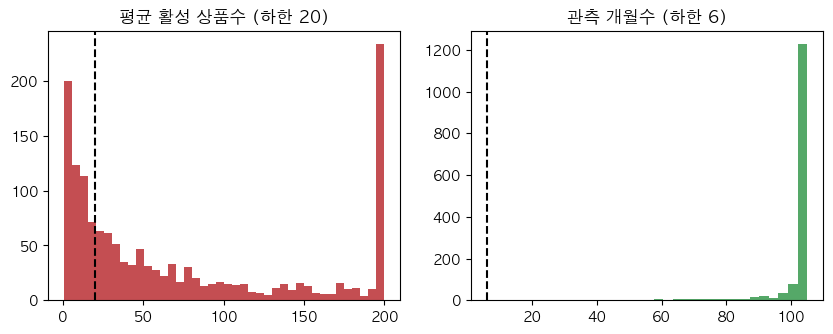

In [4]:
agg = (month.group_by("niche").agg(
        pl.len().alias("n_months"),
        pl.col("n_active_products").mean().alias("avg_active")).to_pandas())
thin = int(((agg["n_months"]<6)|(agg["avg_active"]<20)).sum())
print(f"전체 니치 {len(agg)} · 이 단순 근사로 하한 미달 ~{thin}개 (직관용)")
print("→ 실제 스코어카드는 '최근 12개월 창' 기준의 더 정교한 필터로 906개 채점(제외 548). "
      "여기선 '왜 얇은 니치를 거르나'의 동기만 본다.")
fig,ax=plt.subplots(1,2,figsize=(10,3.5))
ax[0].hist(agg["avg_active"].clip(upper=200), bins=40, color="#c44e52")
ax[0].axvline(20,color="k",ls="--"); ax[0].set_title("평균 활성 상품수 (하한 20)")
ax[1].hist(agg["n_months"], bins=30, color="#55a868")
ax[1].axvline(6,color="k",ls="--"); ax[1].set_title("관측 개월수 (하한 6)")
plt.show()

## 4. 저평점 리뷰에 차별화 단서가 있다 (Q2 동기)
저평점(≤2★) 리뷰는 '무엇이 불만인가'를 직접 말한다. 셀러 주력 니치 Floating Shelves의 저평점 비율과
실제 리뷰 몇 개를 보면, 재질·하드웨어 같은 반복 불만이 보인다 → Q2 aspect 마이닝의 출발점.

In [5]:
fr = pl.read_parquet(M/"fct_review.parquet")
fs = fr.filter(pl.col("niche")=="Floating Shelves")
# Q2와 동일 정의: 저평점 ≤2★ AND 본문 길이 ≥40(노이즈 제외) → 정본 28,816건과 정합
low = fs.filter((pl.col("rating")<=2) & (pl.col("text").fill_null("").str.len_chars()>=40))
print(f"Floating Shelves 리뷰 {fs.height:,} · 저평점(≤2★, 길이≥40) {low.height:,}건 → Q2 마이닝 대상")
for r in (low.sort("helpful_vote",descending=True).head(4).select("review_title").to_series().to_list()):
    print(" -", (r or "")[:90])

Floating Shelves 리뷰 211,623 · 저평점(≤2★, 길이≥40) 28,816건 → Q2 마이닝 대상
 - Area Man Buys Horrible Shelves, Contemplates Life's Choices
 - Smaller dimensions than advertised
 - A half finished product at a fully finished price.
 - Read the reviews!


## 5. 출시 코호트와 생존편향 (Q3 동기)
리뷰 0개로 사라진 상품은 데이터에 없다(생존편향 L-2). 그래서 Q3는 '성공 예측'이 아니라
**'리뷰를 받은 상품 중 안착 vs 조기 정체'** 분류로 정직하게 명명한다. 출시연도별 안착률 드리프트도 보인다.

출시 코호트 연도별 수:
 launch_year      n
        2015 375492
        2016 253844
        2017 248331
        2018 295262
        2019 391829
        2020 410668
        2021 519154
        2022 310523


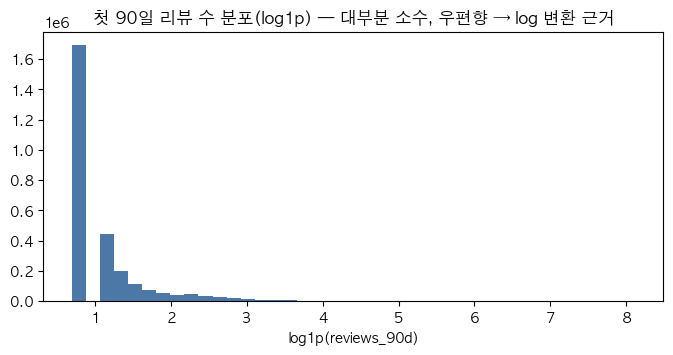

In [6]:
lz = launch.with_columns(
      (pl.col("reviews_12m")-pl.col("reviews_90d")).alias("later")).to_pandas()
by = launch.group_by("launch_year").agg(pl.len().alias("n")).sort("launch_year").to_pandas()
print("출시 코호트 연도별 수:"); print(by.to_string(index=False))
fig,ax=plt.subplots(figsize=(8,3.5))
ax.hist(np.log1p(lz["reviews_90d"].clip(lower=0)), bins=40, color="#4C78A8")
ax.set_title("첫 90일 리뷰 수 분포(log1p) — 대부분 소수, 우편향 → log 변환 근거")
ax.set_xlabel("log1p(reviews_90d)"); plt.show()

## 결론 — 데이터가 강제한 세 렌즈
- **Q1 기회**: 리뷰=수요 프록시의 한계(L-1) → 증가율·상대비교로만. 얇은 니치는 제외.
- **Q2 차별화**: 저평점 리뷰의 반복 불만 → aspect로 조작적 정의.
- **Q3 안착**: 생존편향(L-2)·출시일 프록시(L-3) → '안착 vs 정체' 분류 + point-in-time 피처.

상세 의사결정은 [`docs/decisions.md`], 한계는 [`docs/limitations.md`], 최종 통합은 [`report/final_report.md`].